# Distribuição de indivíduos por split — pigmentação e superpopulação

Histogramas do número de indivíduos por classe (label) em cada split (`train`/`val`/`test`)
para os dois datasets de classificação do genotype-based predictor (1000 Genomes high-coverage):

- **Pigmentação** (`prediction_target="pigmentation"`): label binária derivada da população
  (`strong pigmentation` vs. `weak pigmentation` via `class_map`).
- **Superpopulação** (`prediction_target="superpopulation"`): label = campo `superpopulation`
  bruto do 1000 Genomes (AFR/AMR/EAS/EUR/SAS), sem `class_map` derivado.

O split (family-aware, 70/15/15 por grupo familiar, seed=13) é o mesmo descrito na análise do
notebook [`genotype_cnn_alignment_deeplift_summary.ipynb`](genotype_cnn_alignment_deeplift_summary.ipynb) --
aqui só lemos os artefatos de cache já materializados (`split_index.json` + `dataset_metadata.json`),
sem carregar tensores/modelo, então esta análise é leve (sem `torch`).

In [1]:
%matplotlib inline
import os
import sys
from pathlib import Path

REPO_ROOT = Path("/home/breno/I2CA/genomics")
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))
os.chdir(REPO_ROOT)  # processed_cache_dir in configs is relative to the repo root

import numpy as np
import matplotlib.pyplot as plt

from genomics.predictors.genotype_based.config import load_config, get_dataset_cache_dir
from genomics.predictors.genotype_based.data.cache_report import build_cache_report

SPLIT_ORDER = ["train", "val", "test"]
SPLIT_COLORS = {"train": "#1f77b4", "val": "#ff7f0e", "test": "#2ca02c"}


## Configs e resolução do cache

Usamos as configs `dita_masks_only_1` de cada tarefa -- o split de indivíduos (`build_valid_sample_index_map`
+ `build_family_aware_sample_groups`) não depende de `feature_mode`/`alignment_mapping`, só do
`prediction_target`/`class_map` e da estrutura familiar, então qualquer config-irmã da mesma família
(`pigmentation_binary_*`, `superpopulation_*`) produziria a mesma distribuição de indivíduos.

In [2]:
CONFIG_PATHS = {
    "pigmentation": REPO_ROOT / "configs/predictors/genotype_based/pigmentation/pigmentation_binary_dita_masks_only_1.yaml",
    "superpopulation": REPO_ROOT / "configs/predictors/genotype_based/superpopulation/superpopulation_dita_masks_only_1.yaml",
}

reports = {}
for name, config_path in CONFIG_PATHS.items():
    config = load_config(config_path)
    cache_dir = get_dataset_cache_dir(config)
    assert (cache_dir / "split_index.json").exists(), f"Cache não encontrado para {name}: {cache_dir}"
    reports[name] = build_cache_report(cache_dir)
    print(f"{name}: {reports[name]['total_samples']} indivíduos -- cache={cache_dir}")


pigmentation: 1072 indivíduos -- cache=results/cache/genotype_based_predictor/pigmentation/datasets/rna_seq_H1+H2_32768_ds1_log_shuf_ont3_view90faa3baaf9e
superpopulation: 3202 indivíduos -- cache=results/cache/genotype_based_predictor/superpopulation/datasets/rna_seq_H1+H2_32768_ds1_log_shuf_ont3_viewe36c803e4110


## Label de pigmentação por split

A label não é um campo bruto do 1000 Genomes -- é derivada da população via o `class_map` da config
(`target_definition.derived_targets.pigmentation.class_map`). Agregamos as contagens de população por
split nas duas classes usando esse mapeamento.

In [3]:
def population_counts_to_class_counts(population_counts, class_map):
    """Aggregates per-population sample counts into per-class counts using `class_map`
    (class_name -> list of population codes), the same mapping the dataset pipeline uses to
    derive the pigmentation label from `population` at cache-build time."""
    pop_to_class = {pop: cls for cls, pops in class_map.items() for pop in pops}
    class_counts = {cls: 0 for cls in class_map}
    for population, count in population_counts.items():
        cls = pop_to_class.get(population)
        if cls is not None:
            class_counts[cls] += count
    return class_counts


pig_report = reports["pigmentation"]
pig_class_map = pig_report["target_definition"]["derived_targets"]["pigmentation"]["class_map"]
pig_classes = list(pig_class_map)

pig_counts_by_split = {
    split: population_counts_to_class_counts(pig_report["splits"][split]["population"], pig_class_map)
    for split in SPLIT_ORDER
}
for split in SPLIT_ORDER:
    counts = pig_counts_by_split[split]
    total = sum(counts.values())
    pct = {cls: f"{100 * n / total:.1f}%" for cls, n in counts.items()}
    print(f"{split:>5} (n={total:>4}): {counts}  {pct}")


train (n= 761): {'strong pigmentation': 480, 'weak pigmentation': 281}  {'strong pigmentation': '63.1%', 'weak pigmentation': '36.9%'}
  val (n= 149): {'strong pigmentation': 108, 'weak pigmentation': 41}  {'strong pigmentation': '72.5%', 'weak pigmentation': '27.5%'}
 test (n= 162): {'strong pigmentation': 115, 'weak pigmentation': 47}  {'strong pigmentation': '71.0%', 'weak pigmentation': '29.0%'}


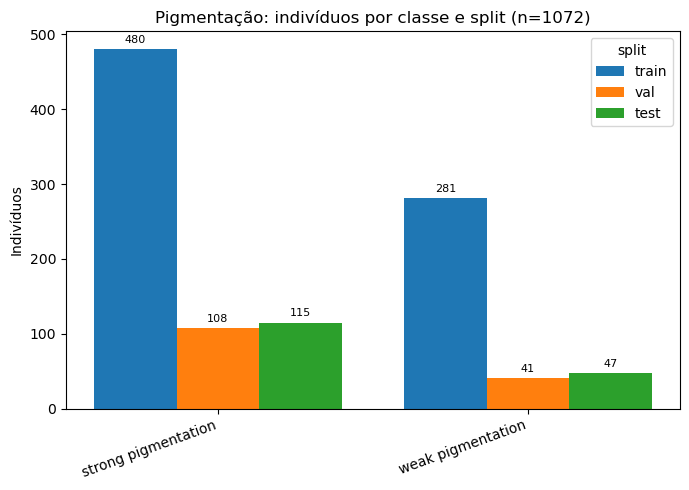

In [4]:
def plot_label_histogram(classes, counts_by_split, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(max(6, len(classes) * 2.2), 5))
    x = np.arange(len(classes))
    width = 0.8 / len(SPLIT_ORDER)
    for i, split in enumerate(SPLIT_ORDER):
        offset = (i - (len(SPLIT_ORDER) - 1) / 2) * width
        values = [counts_by_split[split].get(cls, 0) for cls in classes]
        bars = ax.bar(x + offset, values, width=width, label=split, color=SPLIT_COLORS[split])
        for bar in bars:
            height = bar.get_height()
            if height:
                ax.annotate(f"{int(height)}", xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=20, ha="right")
    ax.set_ylabel("Indivíduos")
    ax.set_title(title)
    ax.legend(title="split")
    return ax


fig, ax = plt.subplots(figsize=(7, 5))
plot_label_histogram(
    pig_classes, pig_counts_by_split,
    title=f"Pigmentação: indivíduos por classe e split (n={pig_report['total_samples']})",
    ax=ax,
)
fig.tight_layout()
plt.show()


## Label de superpopulação por split

Aqui a label *é* o campo `superpopulation` bruto (`known_classes=null`, sem `class_map` derivado),
então usamos a contagem já calculada por `build_cache_report` diretamente.

In [5]:
superpop_report = reports["superpopulation"]
superpop_classes = sorted({cls for split in SPLIT_ORDER for cls in superpop_report["splits"][split]["superpopulation"]})
superpop_counts_by_split = {split: superpop_report["splits"][split]["superpopulation"] for split in SPLIT_ORDER}

for split in SPLIT_ORDER:
    counts = superpop_counts_by_split[split]
    total = sum(counts.values())
    pct = {cls: f"{100 * n / total:.1f}%" for cls, n in counts.items()}
    print(f"{split:>5} (n={total:>4}): {counts}  {pct}")


train (n=2237): {'AFR': 610, 'AMR': 361, 'EAS': 427, 'EUR': 417, 'SAS': 422}  {'AFR': '27.3%', 'AMR': '16.1%', 'EAS': '19.1%', 'EUR': '18.6%', 'SAS': '18.9%'}
  val (n= 468): {'AFR': 147, 'AMR': 55, 'EAS': 81, 'EUR': 92, 'SAS': 93}  {'AFR': '31.4%', 'AMR': '11.8%', 'EAS': '17.3%', 'EUR': '19.7%', 'SAS': '19.9%'}
 test (n= 497): {'AFR': 136, 'AMR': 74, 'EAS': 77, 'EUR': 124, 'SAS': 86}  {'AFR': '27.4%', 'AMR': '14.9%', 'EAS': '15.5%', 'EUR': '24.9%', 'SAS': '17.3%'}


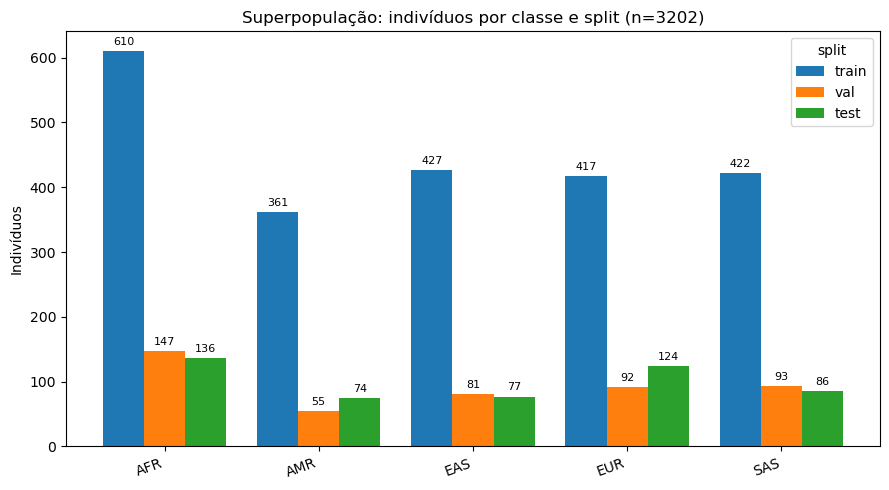

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_label_histogram(
    superpop_classes, superpop_counts_by_split,
    title=f"Superpopulação: indivíduos por classe e split (n={superpop_report['total_samples']})",
    ax=ax,
)
fig.tight_layout()
plt.show()


## Lado a lado

As duas distribuições numa única figura, para comparação direta -- inclusive do desbalanceamento
introduzido pelo split family-aware não estratificado (ver proporções por classe/split acima:
nenhuma delas é constante entre `train`/`val`/`test`, como esperado de um split que agrupa por
família sem controlar a proporção populacional).

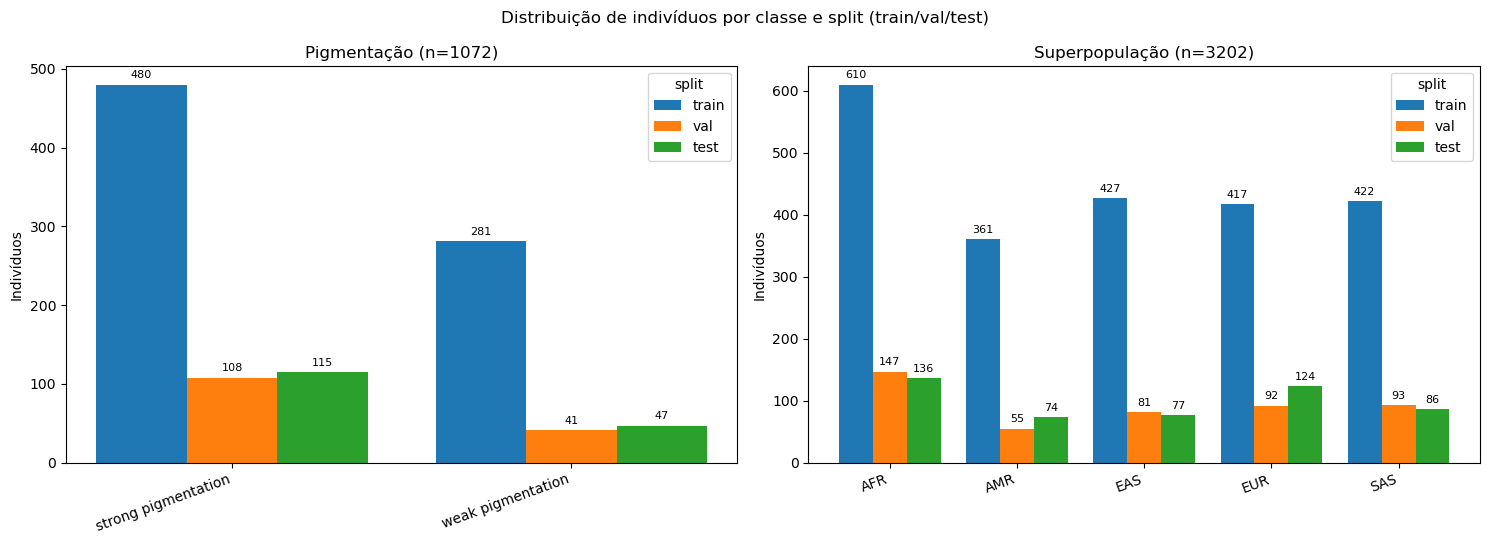

Salvo em /home/breno/I2CA/genomics/notebooks/.cache/dataset_label_distributions/pigmentation_and_superpopulation_by_split.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
plot_label_histogram(pig_classes, pig_counts_by_split,
                      title=f"Pigmentação (n={pig_report['total_samples']})", ax=axes[0])
plot_label_histogram(superpop_classes, superpop_counts_by_split,
                      title=f"Superpopulação (n={superpop_report['total_samples']})", ax=axes[1])
fig.suptitle("Distribuição de indivíduos por classe e split (train/val/test)")
fig.tight_layout()

OUT_DIR = REPO_ROOT / "notebooks" / ".cache" / "dataset_label_distributions"
OUT_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT_DIR / "pigmentation_and_superpopulation_by_split.png", dpi=160)
plt.show()
print(f"Salvo em {OUT_DIR / 'pigmentation_and_superpopulation_by_split.png'}")
